# FailBench Dataset Visualization

Visualize the generated failure dataset: pre/post-failure RGB, 3D contact clouds, per-failure-mode breakdowns, and dataset statistics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D

DATASET_DIR = Path("datasets/v5")
manifest = pd.read_csv(DATASET_DIR / "manifest.csv")
print(f"Dataset: {len(manifest)} samples  (v5 — broadened contact tracking, 1N threshold)")
manifest.head()

Dataset: 20 samples  (v5 — broadened contact tracking, 1N threshold)


,experiment_id,trajectory_file,seed,fail_phase,fail_step,num_contacts,num_failure_modes,had_any_collision,impacted_geom_ids,npz_file
0,exp_00000,scene_level2_RRTConnect_new_baseline.pkl,0,7,2,73884,6,True,0;65;68;69;70;71;72;73;76;77;78;79;80;81;84;89...,exp_00000.npz
1,exp_00001,scene_level2_RRTConnect_new_baseline.pkl,1,7,1,73779,6,True,0;65;68;69;70;71;72;73;76;77;78;79;80;81;84;89...,exp_00001.npz
2,exp_00002,scene_level2_RRTConnect_new_baseline.pkl,2,7,1,73779,6,True,0;65;68;69;70;71;72;73;76;77;78;79;80;81;84;89...,exp_00002.npz
3,exp_00003,scene_level2_RRTConnect_new_baseline.pkl,3,7,1,73779,6,True,0;65;68;69;70;71;72;73;76;77;78;79;80;81;84;89...,exp_00003.npz
4,exp_00004,scene_level2_RRTConnect_new_baseline.pkl,4,7,1,73779,6,True,0;65;68;69;70;71;72;73;76;77;78;79;80;81;84;89...,exp_00004.npz


## 1. Dataset Overview

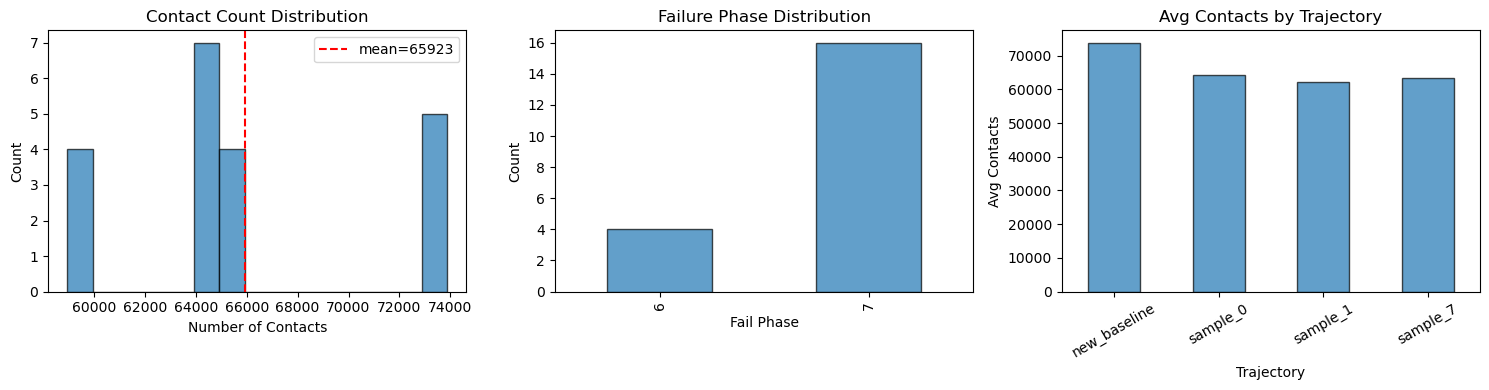

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Contact count distribution
axes[0].hist(manifest["num_contacts"], bins=15, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Number of Contacts")
axes[0].set_ylabel("Count")
axes[0].set_title("Contact Count Distribution")
axes[0].axvline(manifest["num_contacts"].mean(), color="red", ls="--", label=f"mean={manifest['num_contacts'].mean():.0f}")
axes[0].legend()

# Failure phase distribution
manifest["fail_phase"].value_counts().sort_index().plot.bar(ax=axes[1], edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Fail Phase")
axes[1].set_ylabel("Count")
axes[1].set_title("Failure Phase Distribution")

# Contacts by trajectory file
manifest["traj_short"] = manifest["trajectory_file"].apply(lambda x: Path(x).stem.replace("scene_level2_RRTConnect_", ""))
manifest.groupby("traj_short")["num_contacts"].mean().plot.bar(ax=axes[2], edgecolor="black", alpha=0.7)
axes[2].set_xlabel("Trajectory")
axes[2].set_ylabel("Avg Contacts")
axes[2].set_title("Avg Contacts by Trajectory")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 2. Single Sample: Pre/Post-Failure RGB

In [3]:
# Load a sample
SAMPLE_IDX = 0
npz_file = DATASET_DIR / manifest.iloc[SAMPLE_IDX]["npz_file"]
sample = np.load(npz_file, allow_pickle=True)

print("NPZ keys:", list(sample.keys()))
print(f"Contacts: {len(sample['contact_positions'])}")
print(f"Failure modes: {sample['failure_modes']}")
print(f"Failure probs: {sample['failure_probs']}")
print(f"EE position: {sample['pre_ee_pos']}")
print(f"Joint positions: {sample['pre_qpos']}")

NPZ keys: ['pre_rgb', 'pre_qpos', 'pre_qvel', 'pre_ee_pos', 'pre_gripper_ctrl', 'contact_positions', 'contact_forces', 'contact_geom_pairs', 'contact_failure_id', 'failure_modes', 'failure_probs', 'impacted_geom_ids', 'fail_phase', 'fail_step', 'seed', 'post_rgb']
Contacts: 73884
Failure modes: ['gripper_open' 'slippery_grip' 'single_joint' 'single_joint'
 'multi_joint' 'all_joints']
Failure probs: [0.35 0.25 0.15 0.1  0.1  0.05]
EE position: [ 0.01173991 -0.34701054  0.54383768]
Joint positions: [ 1.20407855  0.63554752 -2.88280696 -2.0924708   0.15333805  1.45065759
 -0.92126454]


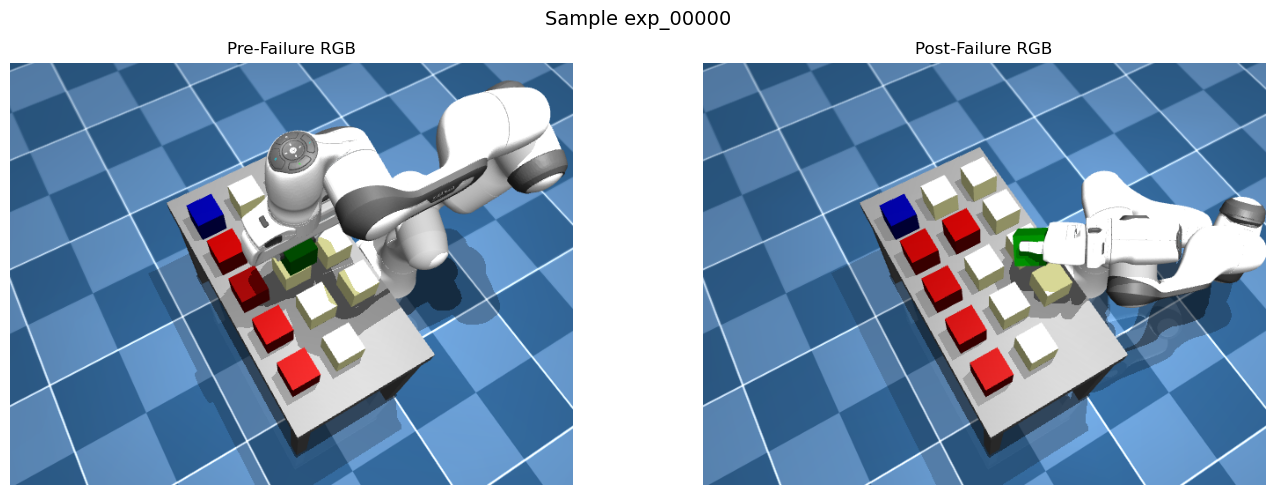

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(sample["pre_rgb"])
axes[0].set_title("Pre-Failure RGB")
axes[0].axis("off")

if "post_rgb" in sample and sample["post_rgb"].shape[0] > 0:
    axes[1].imshow(sample["post_rgb"])
    axes[1].set_title("Post-Failure RGB")
else:
    axes[1].text(0.5, 0.5, "No post-failure RGB", ha="center", va="center", fontsize=14)
axes[1].axis("off")

plt.suptitle(f"Sample {manifest.iloc[SAMPLE_IDX]['experiment_id']}", fontsize=14)
plt.tight_layout()
plt.show()

## 3. 3D Contact Point Cloud (Aggregate)

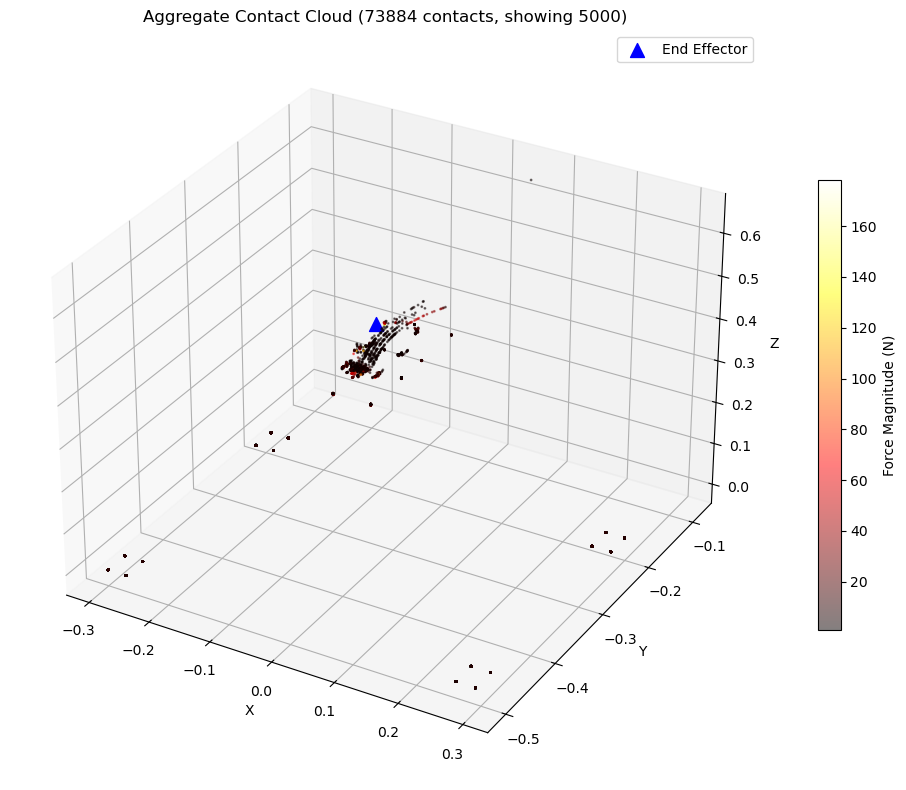

In [5]:
positions = sample["contact_positions"]
forces = sample["contact_forces"]
force_mag = np.linalg.norm(forces[:, :3], axis=1)  # linear force magnitude

# Subsample for plotting if too many contacts
MAX_PLOT = 5000
if len(positions) > MAX_PLOT:
    idx = np.random.choice(len(positions), MAX_PLOT, replace=False)
    pos_plot = positions[idx]
    force_plot = force_mag[idx]
else:
    pos_plot = positions
    force_plot = force_mag

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    pos_plot[:, 0], pos_plot[:, 1], pos_plot[:, 2],
    c=force_plot, cmap="hot", s=1, alpha=0.5,
)
fig.colorbar(sc, ax=ax, label="Force Magnitude (N)", shrink=0.6)

# Mark EE position
ee = sample["pre_ee_pos"]
ax.scatter(*ee, c="blue", s=100, marker="^", label="End Effector", zorder=5)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"Aggregate Contact Cloud ({len(positions)} contacts, showing {len(pos_plot)})")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Contacts by Failure Mode

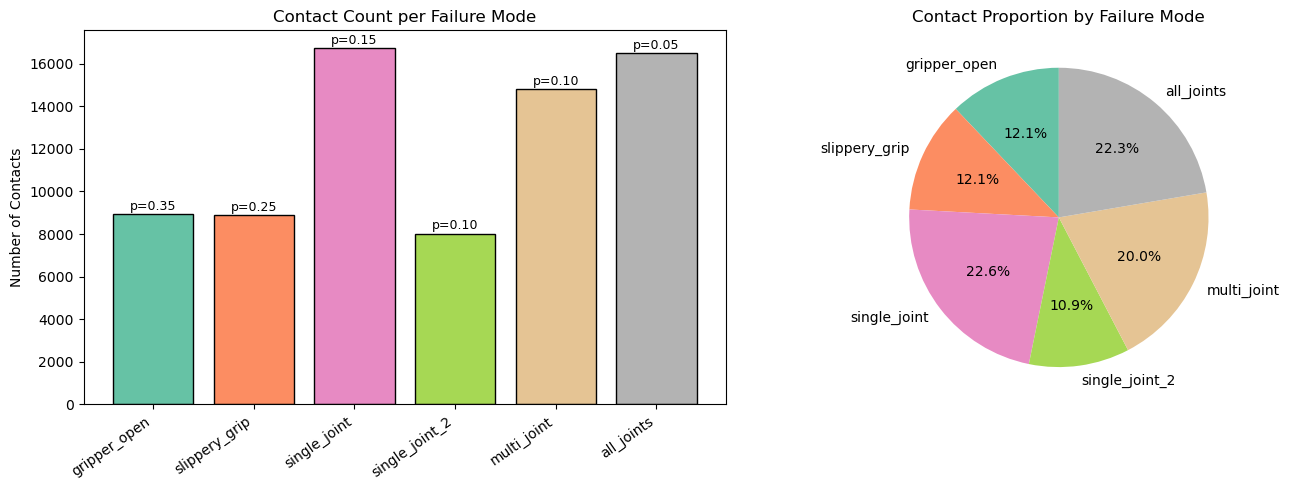

In [6]:
failure_ids = sample["contact_failure_id"]
failure_modes = list(sample["failure_modes"])
failure_probs = sample["failure_probs"]

# Count contacts per mode (use index as key to handle duplicate mode names)
mode_counts = []
mode_labels = []
for i, mode in enumerate(failure_modes):
    count = int(np.sum(failure_ids == i))
    mode_counts.append(count)
    # Disambiguate duplicate names by appending index
    label = mode if failure_modes[:i].count(mode) == 0 else f"{mode}_{failure_modes[:i].count(mode)+1}"
    mode_labels.append(label)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: contact counts per mode
colors = plt.cm.Set2(np.linspace(0, 1, len(failure_modes)))
bars = axes[0].bar(range(len(failure_modes)), mode_counts, color=colors, edgecolor="black")
axes[0].set_xticks(range(len(failure_modes)))
axes[0].set_xticklabels(mode_labels, rotation=35, ha="right")
axes[0].set_ylabel("Number of Contacts")
axes[0].set_title("Contact Count per Failure Mode")
for bar, prob in zip(bars, failure_probs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"p={prob:.2f}", ha="center", va="bottom", fontsize=9)

# Pie chart: proportion
axes[1].pie(mode_counts, labels=mode_labels, autopct="%1.1f%%",
            colors=colors, startangle=90)
axes[1].set_title("Contact Proportion by Failure Mode")

plt.tight_layout()
plt.show()

## 5. Per-Mode 3D Contact Clouds (Side by Side)

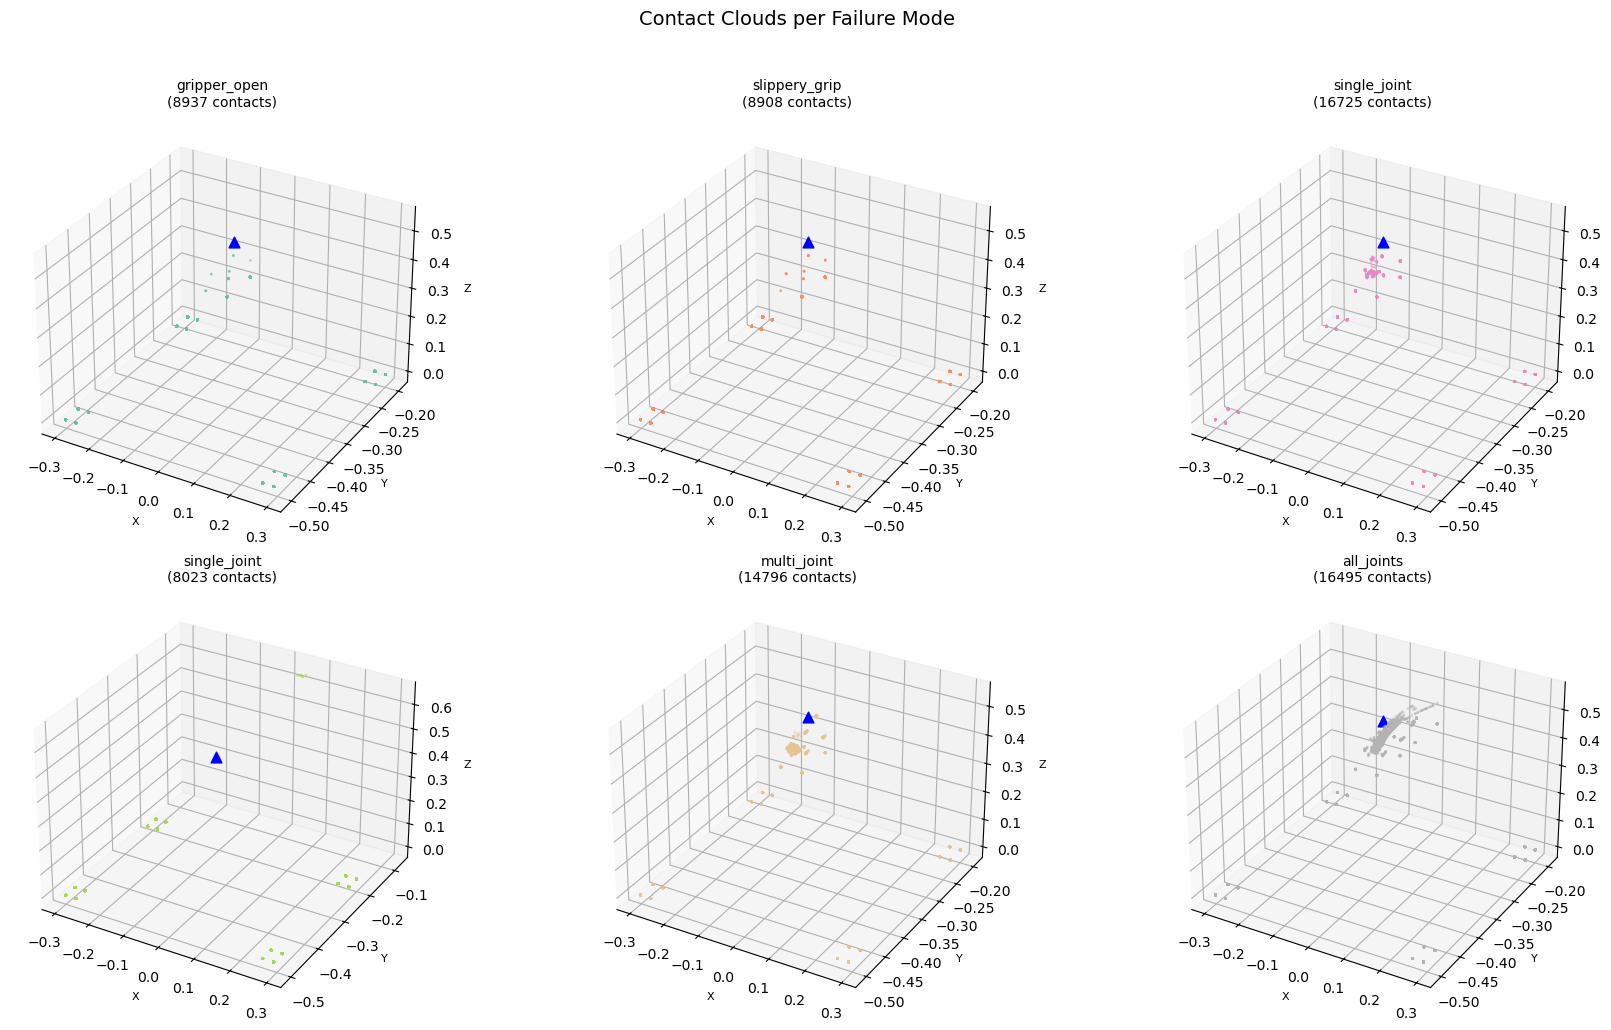

In [7]:
n_modes = len(failure_modes)
cols = min(3, n_modes)
rows = (n_modes + cols - 1) // cols
fig = plt.figure(figsize=(6 * cols, 5 * rows))

for i, mode in enumerate(failure_modes):
    ax = fig.add_subplot(rows, cols, i + 1, projection="3d")
    mask = failure_ids == i
    pts = positions[mask]

    if len(pts) > 2000:
        idx = np.random.choice(len(pts), 2000, replace=False)
        pts = pts[idx]

    if len(pts) > 0:
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=1, alpha=0.4, c=colors[i:i+1])
    ax.scatter(*ee, c="blue", s=60, marker="^", zorder=5)
    ax.set_title(f"{mode}\n({int(mask.sum())} contacts)", fontsize=10)
    ax.set_xlabel("X", fontsize=8)
    ax.set_ylabel("Y", fontsize=8)
    ax.set_zlabel("Z", fontsize=8)

plt.suptitle("Contact Clouds per Failure Mode", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Impacted Geometry Analysis

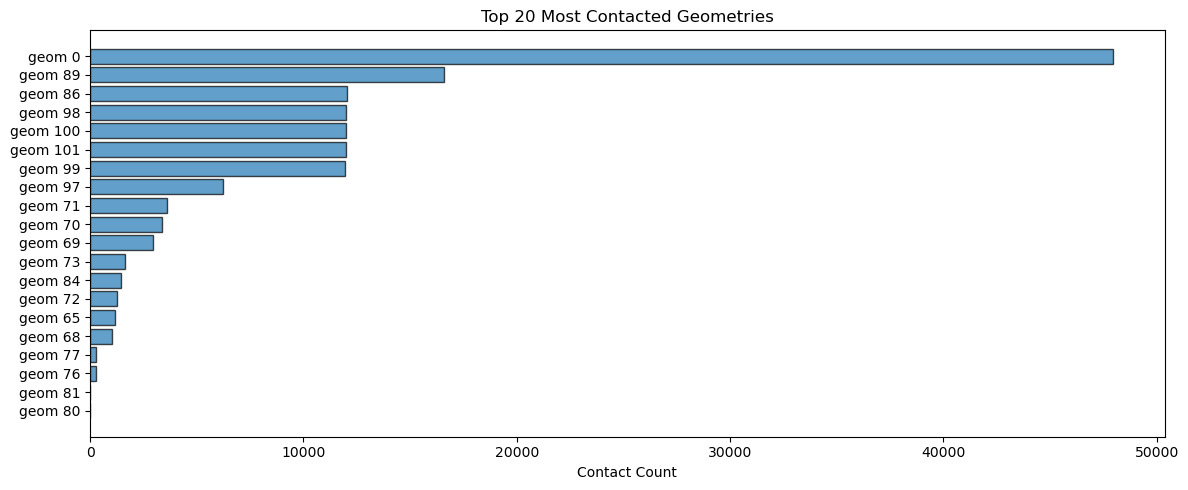

Impacted geom IDs (from manifest): 0;65;68;69;70;71;72;73;76;77;78;79;80;81;84;89;97;98;99;100;101


In [8]:
geom_pairs = sample["contact_geom_pairs"]

# Count how often each geom ID appears
all_geoms = np.concatenate([geom_pairs[:, 0], geom_pairs[:, 1]])
unique_geoms, geom_counts = np.unique(all_geoms, return_counts=True)

# Sort by frequency
sort_idx = np.argsort(-geom_counts)
top_n = min(20, len(unique_geoms))

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(range(top_n), geom_counts[sort_idx[:top_n]], edgecolor="black", alpha=0.7)
ax.set_yticks(range(top_n))
ax.set_yticklabels([f"geom {unique_geoms[i]}" for i in sort_idx[:top_n]])
ax.set_xlabel("Contact Count")
ax.set_title(f"Top {top_n} Most Contacted Geometries")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Impacted geom IDs (from manifest): {manifest.iloc[SAMPLE_IDX]['impacted_geom_ids']}")

## 7. Force Distribution Analysis

/tmp/ipykernel_3856123/3839096300.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(mode_forces, labels=mode_labels, patch_artist=True, showfliers=False)


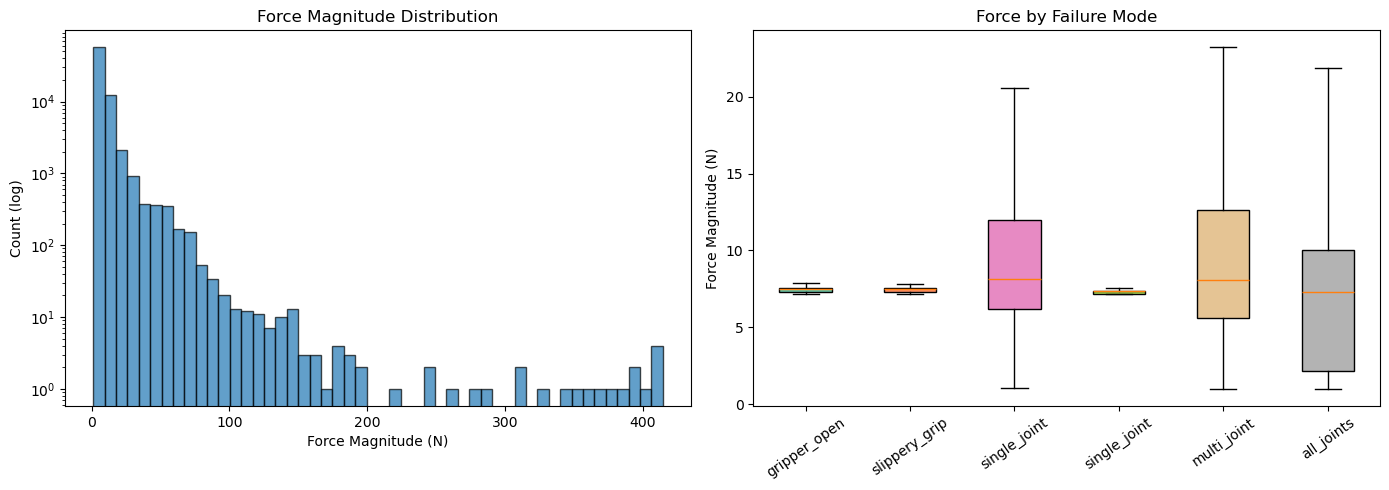

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall force magnitude distribution (log scale)
force_mag_all = np.linalg.norm(forces[:, :3], axis=1)
axes[0].hist(force_mag_all[force_mag_all > 0], bins=50, edgecolor="black", alpha=0.7, log=True)
axes[0].set_xlabel("Force Magnitude (N)")
axes[0].set_ylabel("Count (log)")
axes[0].set_title("Force Magnitude Distribution")

# Force magnitude by failure mode (box plot)
mode_forces = []
mode_labels = []
for i, mode in enumerate(failure_modes):
    mask = failure_ids == i
    fm = np.linalg.norm(forces[mask, :3], axis=1)
    if len(fm) > 0:
        mode_forces.append(fm)
        mode_labels.append(mode)

bp = axes[1].boxplot(mode_forces, labels=mode_labels, patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], colors[:len(mode_forces)]):
    patch.set_facecolor(c)
axes[1].set_ylabel("Force Magnitude (N)")
axes[1].set_title("Force by Failure Mode")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

## 8. Cross-Sample Comparison

In [10]:
# Load all samples and compare contact spatial extent
sample_stats = []
for _, row in manifest.iterrows():
    s = np.load(DATASET_DIR / row["npz_file"], allow_pickle=True)
    pos = s["contact_positions"]
    frc = np.linalg.norm(s["contact_forces"][:, :3], axis=1)
    sample_stats.append({
        "experiment_id": row["experiment_id"],
        "n_contacts": len(pos),
        "mean_force": frc.mean() if len(frc) > 0 else 0,
        "max_force": frc.max() if len(frc) > 0 else 0,
        "x_spread": np.ptp(pos[:, 0]) if len(pos) > 0 else 0,
        "y_spread": np.ptp(pos[:, 1]) if len(pos) > 0 else 0,
        "z_spread": np.ptp(pos[:, 2]) if len(pos) > 0 else 0,
        "ee_x": s["pre_ee_pos"][0],
        "ee_y": s["pre_ee_pos"][1],
        "ee_z": s["pre_ee_pos"][2],
    })

stats_df = pd.DataFrame(sample_stats)
stats_df

,experiment_id,n_contacts,mean_force,max_force,x_spread,y_spread,z_spread,ee_x,ee_y,ee_z
0,exp_00000,73884,9.095301,414.674011,0.590007,0.429026,0.644197,0.011740,-0.347011,0.543838
1,exp_00001,73779,8.708261,405.314209,0.590006,0.430053,0.644581,0.011844,-0.346198,0.544806
2,exp_00002,73779,8.708261,405.314209,0.590006,0.430053,0.644581,0.011844,-0.346198,0.544806
3,exp_00003,73779,8.708261,405.314209,0.590006,0.430053,0.644581,0.011844,-0.346198,0.544806
4,exp_00004,73779,8.708261,405.314209,0.590006,0.430053,0.644581,0.011844,-0.346198,0.544806
5,exp_00005,65733,10.218598,320.851807,0.590119,0.310226,0.641088,0.142463,-0.463452,0.545467
6,exp_00006,65076,10.278499,381.654938,0.590117,0.310223,0.641824,0.142513,-0.462826,0.546797
7,exp_00007,65076,10.278499,381.654938,0.590117,0.310223,0.641824,0.142513,-0.462826,0.546797
8,exp_00008,59677,9.426748,343.343079,0.590079,0.482885,0.642319,0.200228,-0.250522,0.584389
9,exp_00009,65733,10.218598,320.851807,0.590119,0.310226,0.641088,0.142463,-0.463452,0.545467


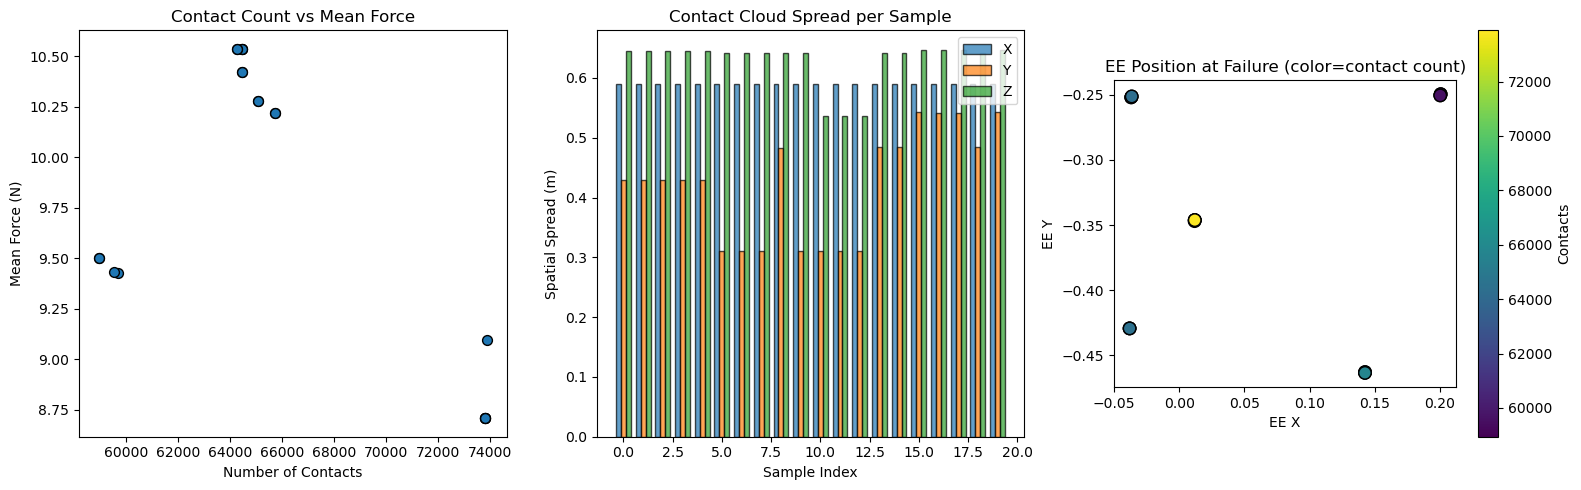

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Contact count vs mean force
axes[0].scatter(stats_df["n_contacts"], stats_df["mean_force"], s=50, edgecolor="black")
axes[0].set_xlabel("Number of Contacts")
axes[0].set_ylabel("Mean Force (N)")
axes[0].set_title("Contact Count vs Mean Force")

# Spatial spread
x = np.arange(len(stats_df))
w = 0.25
axes[1].bar(x - w, stats_df["x_spread"], w, label="X", edgecolor="black", alpha=0.7)
axes[1].bar(x, stats_df["y_spread"], w, label="Y", edgecolor="black", alpha=0.7)
axes[1].bar(x + w, stats_df["z_spread"], w, label="Z", edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Sample Index")
axes[1].set_ylabel("Spatial Spread (m)")
axes[1].set_title("Contact Cloud Spread per Sample")
axes[1].legend()

# EE positions across samples (top-down view)
axes[2].scatter(stats_df["ee_x"], stats_df["ee_y"], c=stats_df["n_contacts"],
                cmap="viridis", s=80, edgecolor="black")
axes[2].set_xlabel("EE X")
axes[2].set_ylabel("EE Y")
axes[2].set_title("EE Position at Failure (color=contact count)")
fig.colorbar(axes[2].collections[0], ax=axes[2], label="Contacts")
axes[2].set_aspect("equal")

plt.tight_layout()
plt.show()

## 9. Multi-Sample RGB Grid

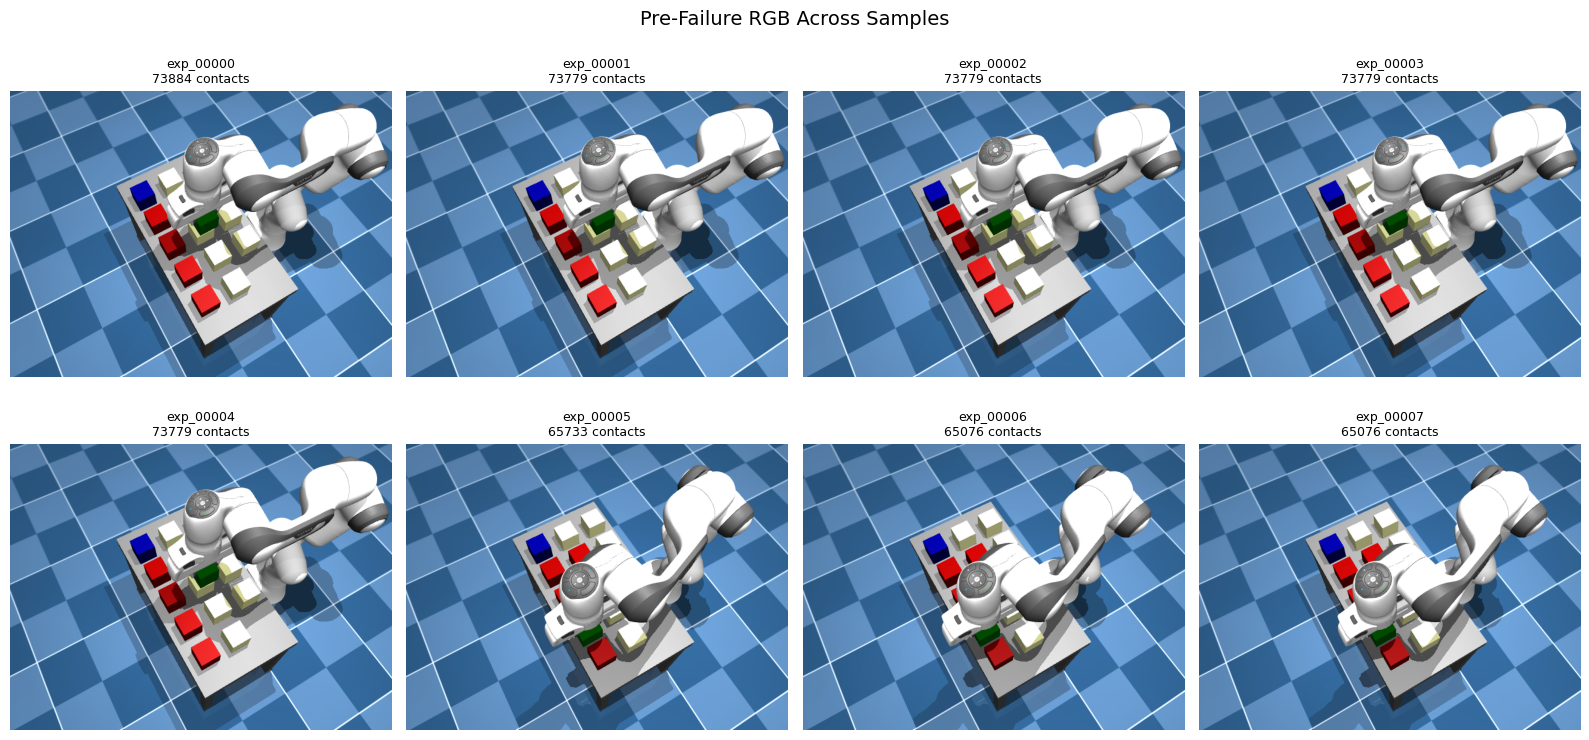

In [12]:
n_show = min(8, len(manifest))
cols = 4
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

for i in range(n_show):
    s = np.load(DATASET_DIR / manifest.iloc[i]["npz_file"], allow_pickle=True)
    axes[i].imshow(s["pre_rgb"])
    axes[i].set_title(f"{manifest.iloc[i]['experiment_id']}\n{manifest.iloc[i]['num_contacts']} contacts", fontsize=9)
    axes[i].axis("off")

for i in range(n_show, len(axes)):
    axes[i].axis("off")

plt.suptitle("Pre-Failure RGB Across Samples", fontsize=14)
plt.tight_layout()
plt.show()

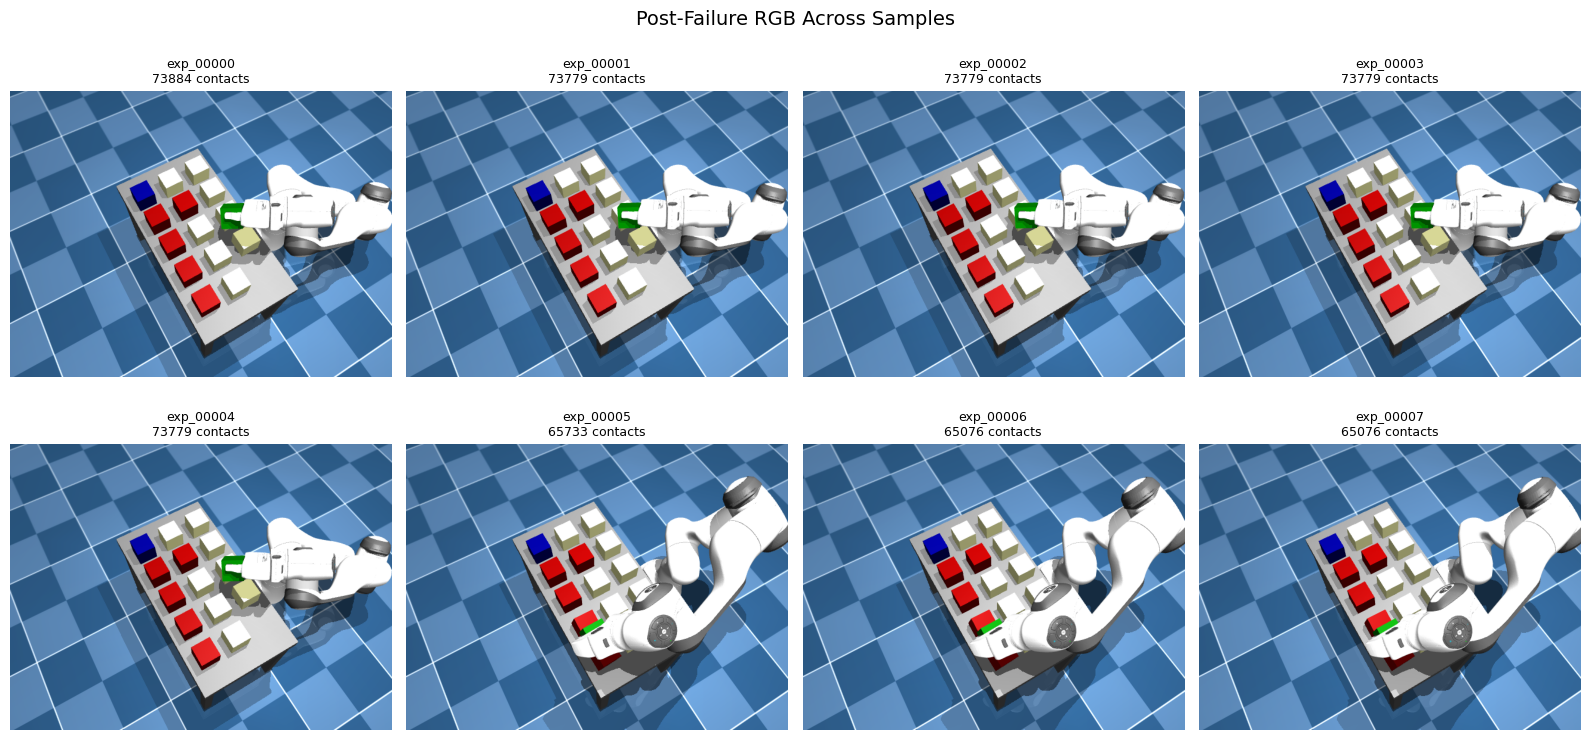

In [13]:
n_show = min(8, len(manifest))
cols = 4
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

for i in range(n_show):
    s = np.load(DATASET_DIR / manifest.iloc[i]["npz_file"], allow_pickle=True)
    axes[i].imshow(s["post_rgb"])
    axes[i].set_title(f"{manifest.iloc[i]['experiment_id']}\n{manifest.iloc[i]['num_contacts']} contacts", fontsize=9)
    axes[i].axis("off")

for i in range(n_show, len(axes)):
    axes[i].axis("off")

plt.suptitle("Post-Failure RGB Across Samples", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Penetration Depth Analysis

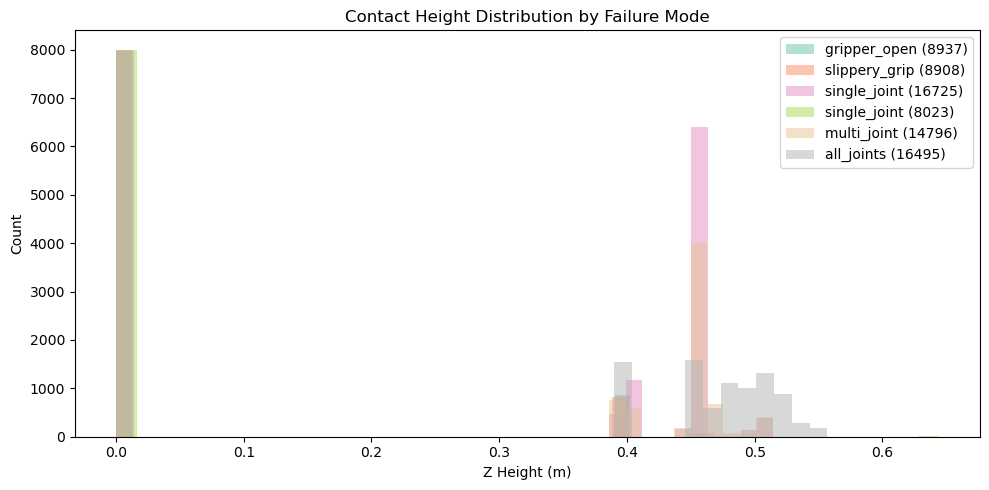

In [14]:
# Reload sample 0 for detailed analysis
sample = np.load(DATASET_DIR / manifest.iloc[SAMPLE_IDX]["npz_file"], allow_pickle=True)
positions = sample["contact_positions"]
failure_ids = sample["contact_failure_id"]
failure_modes = list(sample["failure_modes"])

# Contact height (Z) distribution per failure mode
fig, ax = plt.subplots(figsize=(10, 5))
for i, mode in enumerate(failure_modes):
    mask = failure_ids == i
    z_vals = positions[mask, 2]
    if len(z_vals) > 0:
        ax.hist(z_vals, bins=40, alpha=0.5, label=f"{mode} ({mask.sum()})", color=colors[i])

ax.set_xlabel("Z Height (m)")
ax.set_ylabel("Count")
ax.set_title("Contact Height Distribution by Failure Mode")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Contact-to-Image Projection & Per-Object Force Summary

Project 3D contact points onto the pre-failure RGB image and show which objects were contacted with what force.

In [15]:
from planner.experiments.process_contacts import process_npz, print_summary

SCENE_XML = "franka_emika_panda/scene_level2.xml"
SAMPLE_NPZ = str(DATASET_DIR / manifest.iloc[SAMPLE_IDX]["npz_file"])

result = process_npz(SAMPLE_NPZ, SCENE_XML,
                     camera_lookat=[0.0, -0.35, 0.4],
                     camera_distance=1.1,
                     camera_azimuth=150,
                     camera_elevation=-65)
print_summary(result)


Contact Summary — 73,884 total contacts
  hand vs object3
    at (0.012, -0.329, 0.507)
    peak force: 414.67 N, mean: 39.02 N, contacts: 1159
  object3 vs obstacle_soft7
    at (0.004, -0.344, 0.454)
    peak force: 188.20 N, mean: 9.79 N, contacts: 4136
  left_finger vs obstacle_soft7
    at (0.002, -0.369, 0.456)
    peak force: 139.10 N, mean: 9.47 N, contacts: 7135
  obstacle_soft7 vs simple_table
    at (0.008, -0.350, 0.399)
    peak force: 99.34 N, mean: 12.58 N, contacts: 5304
  left_finger vs object3
    at (0.013, -0.354, 0.492)
    peak force: 49.93 N, mean: 2.47 N, contacts: 6702
  floor vs simple_table
    at (-0.000, -0.350, -0.000)
    peak force: 38.75 N, mean: 8.78 N, contacts: 47967
  obstacle_soft3 vs right_finger
    at (0.017, -0.274, 0.457)
    peak force: 27.21 N, mean: 12.63 N, contacts: 546
  obstacle_soft3 vs simple_table
    at (0.000, -0.248, 0.399)
    peak force: 18.83 N, mean: 7.92 N, contacts: 911
  object3 vs right_finger
    at (0.047, -0.093, 0.637

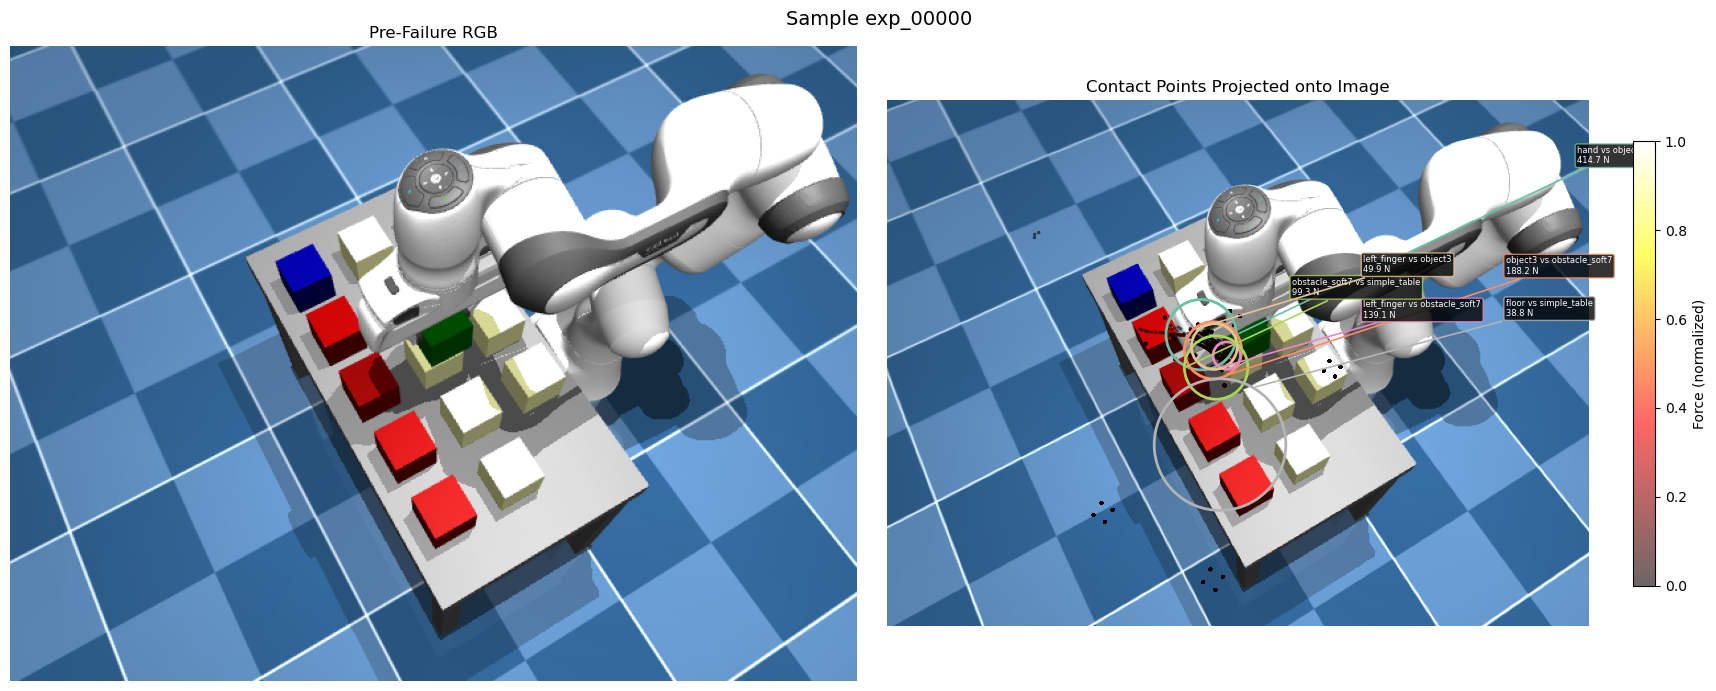

In [16]:
# Annotated image: contact points overlaid on pre-failure RGB
import matplotlib.patches as mpatches

pre_rgb = result["pre_rgb"]
pixels = result["pixels"]
mask = result["in_frame"]
force_mags = result["force_magnitudes"]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: original image
axes[0].imshow(pre_rgb)
axes[0].set_title("Pre-Failure RGB")
axes[0].axis("off")

# Right: image with contact overlay
axes[1].imshow(pre_rgb)

if mask.any():
    vis_px = pixels[mask]
    vis_f = force_mags[mask]

    MAX_VIS = 5000
    if len(vis_px) > MAX_VIS:
        idx = np.random.default_rng(0).choice(len(vis_px), MAX_VIS, replace=False)
        vis_px, vis_f = vis_px[idx], vis_f[idx]

    f_min, f_max = vis_f.min(), vis_f.max()
    f_norm = (vis_f - f_min) / (f_max - f_min) if f_max > f_min else np.zeros_like(vis_f)

    # Draw contact point scatter
    sc = axes[1].scatter(vis_px[:, 0], vis_px[:, 1], c=f_norm,
                         cmap="hot", s=6, alpha=0.6, edgecolors="none", zorder=2)
    plt.colorbar(sc, ax=axes[1], label="Force (normalized)", shrink=0.7)

    # Draw a circle at each top contact pair's mean position
    top_pairs = sorted(result["summary"].items(), key=lambda x: -x[1]["peak_force_N"])[:6]
    label_positions = []
    pair_colors = plt.cm.Set2(np.linspace(0, 1, len(top_pairs)))

    for k, (pair_name, info) in enumerate(top_pairs):
        obj_pixels = []
        for i, c in enumerate(result["contacts"]):
            pair = tuple(sorted([c["object_a"], c["object_b"]]))
            if f"{pair[0]} vs {pair[1]}" == pair_name and result["in_frame"][i]:
                obj_pixels.append(result["pixels"][i])
        if not obj_pixels:
            continue

        obj_pixels = np.array(obj_pixels)
        mean_px = obj_pixels.mean(axis=0)
        # Radius proportional to spread of contact cluster
        spread = np.linalg.norm(obj_pixels.std(axis=0)) + 8
        radius = np.clip(spread, 10, 60)

        color = pair_colors[k]
        circle = plt.Circle(mean_px, radius, fill=False,
                            edgecolor=color, linewidth=2, zorder=3)
        axes[1].add_patch(circle)
        label_positions.append((mean_px, pair_name, info["peak_force_N"], color, radius))

    # Spread labels with arrows pointing to circle edge
    n = len(label_positions)
    img_cx = pre_rgb.shape[1] * 0.78
    img_cy = pre_rgb.shape[0] * 0.12
    for k, (mean_px, label, peak_f, color, radius) in enumerate(label_positions):
        angle = (k / max(n, 1)) * 2 * np.pi
        arrow_dx = np.cos(angle)
        arrow_dy = np.sin(angle)
        ann_x = np.clip(img_cx + 130 * np.cos(angle), 10, pre_rgb.shape[1] - 10)
        ann_y = np.clip(img_cy + 70 * np.sin(angle) + k * 40, 10, pre_rgb.shape[0] - 10)
        # Arrow starts from circle edge
        arrow_start = (mean_px[0] + radius * arrow_dx, mean_px[1] + radius * arrow_dy)
        axes[1].annotate(
            f"{label}\n{peak_f:.1f} N",
            xy=arrow_start,
            xytext=(ann_x, ann_y),
            fontsize=6, color="white",
            arrowprops=dict(arrowstyle="-", color=color, lw=1.2),
            bbox=dict(boxstyle="round,pad=0.25", fc="black", ec=color, alpha=0.8),
            zorder=4,
        )

axes[1].set_title("Contact Points Projected onto Image")
axes[1].set_xlim(0, pre_rgb.shape[1])
axes[1].set_ylim(pre_rgb.shape[0], 0)
axes[1].axis("off")

plt.suptitle(f"Sample {manifest.iloc[SAMPLE_IDX]['experiment_id']}", fontsize=14)
plt.tight_layout()
plt.show()

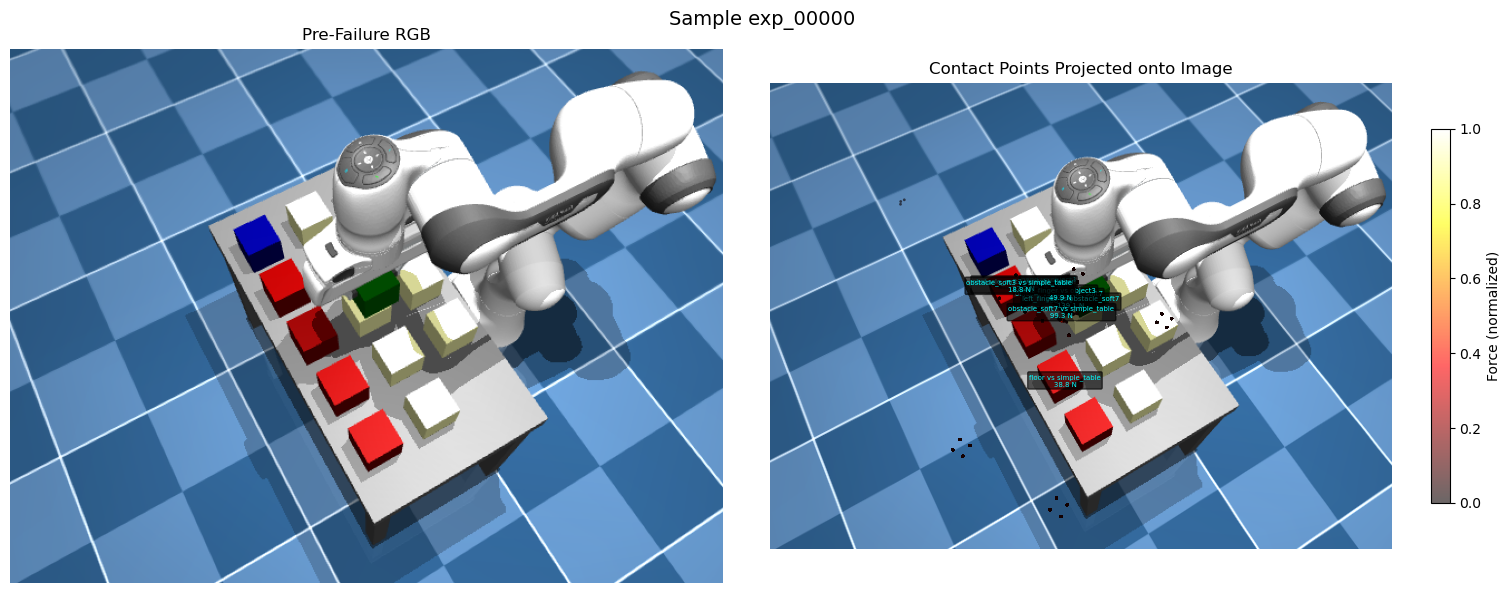

In [17]:
# Annotated image: contact points overlaid on pre-failure RGB
pre_rgb = result["pre_rgb"]
pixels = result["pixels"]
mask = result["in_frame"]
force_mags = result["force_magnitudes"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: original image
axes[0].imshow(pre_rgb)
axes[0].set_title("Pre-Failure RGB")
axes[0].axis("off")

# Right: image with contact overlay
axes[1].imshow(pre_rgb)

if mask.any():
    vis_px = pixels[mask]
    vis_f = force_mags[mask]

    MAX_VIS = 5000
    if len(vis_px) > MAX_VIS:
        idx = np.random.default_rng(0).choice(len(vis_px), MAX_VIS, replace=False)
        vis_px, vis_f = vis_px[idx], vis_f[idx]

    f_min, f_max = vis_f.min(), vis_f.max()
    f_norm = (vis_f - f_min) / (f_max - f_min) if f_max > f_min else np.zeros_like(vis_f)

    sc = axes[1].scatter(vis_px[:, 0], vis_px[:, 1], c=f_norm,
                         cmap="hot", s=4, alpha=0.6, edgecolors="none")
    plt.colorbar(sc, ax=axes[1], label="Force (normalized)", shrink=0.7)

    # Label top contact pairs by peak force
    top_pairs = sorted(result["summary"].items(), key=lambda x: -x[1]["peak_force_N"])[:8]
    for pair_name, info in top_pairs:
        obj_pixels = []
        for i, c in enumerate(result["contacts"]):
            pair = tuple(sorted([c["object_a"], c["object_b"]]))
            pair_label = f"{pair[0]} vs {pair[1]}"
            if pair_label == pair_name and result["in_frame"][i]:
                obj_pixels.append(result["pixels"][i])
        if obj_pixels:
            mean_px = np.mean(obj_pixels, axis=0)
            label = f"{pair_name}\n{info['peak_force_N']:.1f} N"
            axes[1].annotate(label, xy=mean_px, fontsize=5, color="cyan",
                             ha="center", va="bottom",
                             bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.6))

axes[1].set_title("Contact Points Projected onto Image")
axes[1].set_xlim(0, pre_rgb.shape[1])
axes[1].set_ylim(pre_rgb.shape[0], 0)
axes[1].axis("off")

plt.suptitle(f"Sample {manifest.iloc[SAMPLE_IDX]['experiment_id']}", fontsize=14)
plt.tight_layout()
plt.show()